In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

### 1. Loading data

In [2]:
df = pd.read_csv('../data/data.csv')
print(df.shape)
df.info()

(4600, 18)
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float

### 2. data Cleaning

In [3]:
# remove data errors: houses with price = 0
zero_count = (df['price'] == 0).sum()
print(f"Rows with price = 0: {zero_count}")
df = df[df['price'] != 0]
print(f"Shape after cleaning: {df.shape}")

df["age_of_house"] = 2014 - df["yr_built"]
df["is_renovated"] = (df["yr_renovated"] != 0).astype(int)
df["years_since_renovation"] = np.where(
    df["yr_renovated"] != 0,
    2014 - df["yr_renovated"],
    2014 - df["yr_built"]
)

df_cleaned = df.drop(['date', 'street', 'country','yr_renovated','yr_built'], axis=1)

print(df_cleaned.head(10))

Rows with price = 0: 49
Shape after cleaning: (4551, 18)
       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0   313000.0       3.0       1.50         1340      7912     1.5           0   
1  2384000.0       5.0       2.50         3650      9050     2.0           0   
2   342000.0       3.0       2.00         1930     11947     1.0           0   
3   420000.0       3.0       2.25         2000      8030     1.0           0   
4   550000.0       4.0       2.50         1940     10500     1.0           0   
5   490000.0       2.0       1.00          880      6380     1.0           0   
6   335000.0       2.0       2.00         1350      2560     1.0           0   
7   482000.0       4.0       2.50         2710     35868     2.0           0   
8   452500.0       3.0       2.50         2430     88426     1.0           0   
9   640000.0       4.0       2.00         1520      6200     1.5           0   

   view  condition  sqft_above  sqft_basement          city  s

### 3. Understanding the data - Visualising

Average house price: 557905.90
Price range: 7800 — 26590000


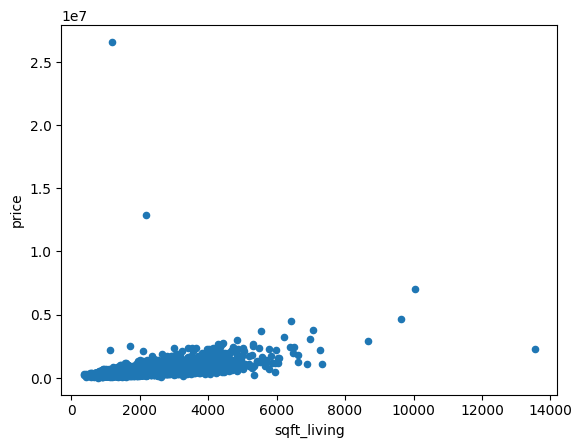

In [4]:
df_cleaned.plot(kind="scatter", x="sqft_living", y="price")

avg_price = df_cleaned["price"].mean()
print(f"Average house price: {avg_price:.2f}")
print(f"Price range: {df_cleaned['price'].min():.0f} — {df_cleaned['price'].max():.0f}")

### 4. Preparing Training and Testing Data

#### 4.1 Splitting data training/test

In [5]:
train_df = df_cleaned.sample(frac=0.8, random_state=42)
test_df = df_cleaned.drop(train_df.index)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

Train: (3641, 16)
Test:  (910, 16)


#### 4.2 Remove outliers - extreme values

In [6]:
# IQR method for outlier removal (training data only)
Q1 = train_df['price'].quantile(0.25)
Q3 = train_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 2.0 * IQR
upper_bound = Q3 + 2.0 * IQR

before = len(train_df)
train_df = train_df[(train_df["price"] >= lower_bound) & (train_df["price"] <= upper_bound)]

print(f"IQR: {IQR:.0f}, Bounds: [{max(0, lower_bound):.0f}, {upper_bound:.0f}]")
print(f"Removed {before - len(train_df)} outliers from training data ({len(train_df)} remaining)")

IQR: 330017, Bounds: [0, 1317033]
Removed 128 outliers from training data (3513 remaining)


#### 4.3 Target Encoding

In [7]:
# compute encoding maps from training data only
city_avg = train_df.groupby("city")["price"].mean()
statezip_avg = train_df.groupby("statezip")["price"].mean()
global_avg = train_df["price"].mean()

# apply to train
train_df["city_encoded"] = train_df["city"].map(city_avg)
train_df["statezip_encoded"] = train_df["statezip"].map(statezip_avg)

# apply to test (fillna handles unseen categories)
test_df["city_encoded"] = test_df["city"].map(city_avg).fillna(global_avg)
test_df["statezip_encoded"] = test_df["statezip"].map(statezip_avg).fillna(global_avg)

# drop original string columns
train_df = train_df.drop(["city", "statezip"], axis=1)
test_df = test_df.drop(["city", "statezip"], axis=1)

print(f"Columns: {train_df.columns.tolist()}")

Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'age_of_house', 'is_renovated', 'years_since_renovation', 'city_encoded', 'statezip_encoded']


#### 4.4 Feature / Target Separation

In [8]:
X_train = train_df.drop("price", axis=1)
y_train = train_df["price"]

X_test = test_df.drop("price", axis=1)
y_test = test_df["price"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (3513, 15), y_train: (3513,)
X_test:  (910, 15), y_test:  (910,)


In [9]:
poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(X_train)
print(X_train.shape)

(3513, 136)


### 5. Normalisation  - Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"Peak to peak (raw):\n{np.ptp(X_train, axis=0)}\n")
print(f"Peak to peak (scaled):\n{np.ptp(X_train_scaled, axis=0)}")

Peak to peak (raw):
[0.00000000e+00 8.00000000e+00 5.75000000e+00 6.26000000e+03
 1.07358000e+06 2.50000000e+00 1.00000000e+00 4.00000000e+00
 4.00000000e+00 4.82000000e+03 2.33000000e+03 1.14000000e+02
 1.00000000e+00 1.14000000e+02 9.11045333e+05 6.89043784e+05
 6.40000000e+01 4.02500000e+01 4.64100000e+04 5.37109000e+06
 1.80000000e+01 6.00000000e+00 2.40000000e+01 3.50000000e+01
 3.45100000e+04 1.44900000e+04 7.91000000e+02 8.00000000e+00
 7.91000000e+02 5.17482223e+06 5.17482223e+06 3.30625000e+01
 3.64650000e+04 3.49120850e+06 1.35000000e+01 3.25000000e+00
 1.80000000e+01 2.25000000e+01 2.85450000e+04 9.35000000e+03
 3.93750000e+02 5.75000000e+00 4.09500000e+02 3.95276871e+06
 3.99664567e+06 4.38200000e+07 3.23290471e+09 1.30100000e+04
 3.83100000e+03 2.37600000e+04 2.26600000e+04 3.25490000e+07
 1.17176000e+07 5.44680000e+05 6.63000000e+03 4.05860000e+05
 4.62706003e+09 4.69836021e+09 1.15394390e+12 1.61049400e+06
 5.96120000e+04 1.43486400e+06 5.36917600e+06 2.15870757e+09
 1.0

### 6. Model Training

In [11]:
model = Ridge(alpha=1000)
model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1000
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [12]:
print(f"Weights:\n{model.coef_}\n")
print(f"Bias: {model.intercept_:.2f}")

Weights:
[    0.         -2676.59713344  5126.57448319 12886.53500182
  2541.55461769    55.38902538  3543.05453172  6386.53495662
 -2894.49513242 11327.2552653   4489.59266557 -1991.85359651
  -252.41555496 -4129.67979134  6786.89691175 19645.41806256
 -6089.10053174  -785.00448758   -95.25801562 -2067.80729857
 -1452.13870311  3605.08081644  -244.03266058 -3664.29505018
   122.4145736   -493.24381289   591.45962787 -1937.22552436
 -2455.94411463  1213.50657735 12127.4124056   1161.06771579
  3066.36513131  -265.58129994   -29.44011138  6126.62176135
  1673.23326672  1598.58229444  2937.6024291   1353.75013849
   697.70487257  -740.3124677  -1191.29271978  3267.29295189
 12818.77099685  2985.12253379  3604.30571949  5601.74881833
 -3942.5803561  -1503.4891073   9291.66381846  3890.71299938
 -1220.75248768  2838.1328585    470.37339815   -84.56467765
  8943.74429742 17174.65748657  2227.52938612   580.61047133
   241.90217631 -3900.94307565  1285.31670438  4966.67513774
 -2439.71858225

### 7. Evaluation

In [13]:
# use scaler fitted on training data (never fit_transform on test)
X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)
predictions = model.predict(X_test_scaled)
predictions_training = model.predict(X_train_scaled)

In [14]:
np.set_printoptions(precision=2)
print(f"Predicted: {predictions[:10]}")
print(f"Actual:    {y_test[:10].values}")

Predicted: [544714.5  550425.04 390887.   499756.54 543665.31 781845.46 510612.26
 554099.17 435166.55 261062.32]
Actual:    [420000. 550000. 490000. 640000. 419000. 698000. 400000. 403000. 335000.
 308500.]


In [15]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Average house price: {avg_price:.2f}")
print(f"Test data RMSE: {rmse:.2f}")
print(f"Test data RMSE as % of avg price: {rmse/avg_price*100:.1f}%")


rmse_training = np.sqrt(mean_squared_error(y_train, predictions_training))
print(f"Train data RMSE: {rmse_training:.2f}")
print(f"Train data RMSE as % of avg price: {rmse_training/avg_price*100:.1f}%")

Average house price: 557905.90
Test data RMSE: 245036.68
Test data RMSE as % of avg price: 43.9%
Train data RMSE: 115709.54
Train data RMSE as % of avg price: 20.7%


In [16]:
train_df.corr()["price"].sort_values() 

is_renovated             -0.063036
age_of_house             -0.048366
years_since_renovation    0.010753
condition                 0.043928
sqft_lot                  0.085246
waterfront                0.100449
sqft_basement             0.248321
view                      0.266874
floors                    0.270951
bedrooms                  0.313681
bathrooms                 0.478840
sqft_above                0.546611
city_encoded              0.575230
sqft_living               0.638265
statezip_encoded          0.686863
price                     1.000000
Name: price, dtype: float64